# **Dilation**

Original Image:


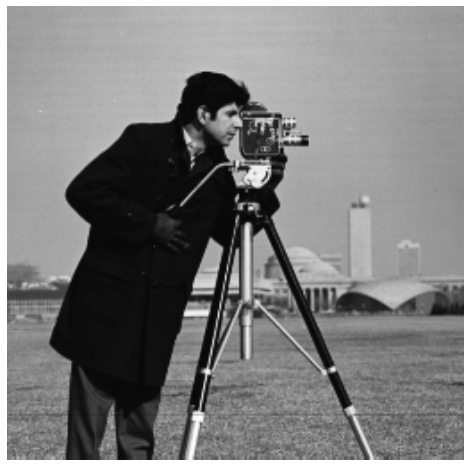


Dilated Image:


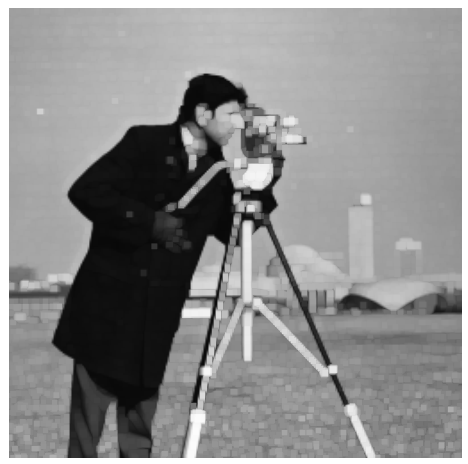

In [3]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow  # Colab-specific display function

# Load grayscale image (upload your own or use a sample)
img = cv2.imread('thr.png', cv2.IMREAD_GRAYSCALE)

# Define kernel (structuring element)
kernel = np.ones((5,5), np.uint8)  # 5x5 square kernel
# Alternative kernels:
# kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7,7))  # Circular
# kernel = cv2.getStructuringElement(cv2.MORPH_CROSS, (5,5))   # Cross-shaped

# Perform dilation
dilated = cv2.dilate(img, kernel, iterations=1)

# Display results (Colab-compatible)
print("Original Image:")
cv2_imshow(img)
print("\nDilated Image:")
cv2_imshow(dilated)

# **Erosion**

Original Image:


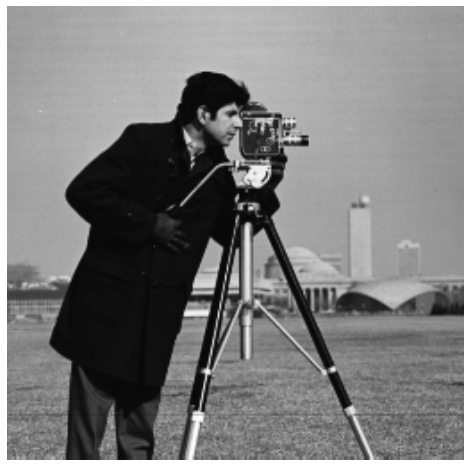


Eroded Image:


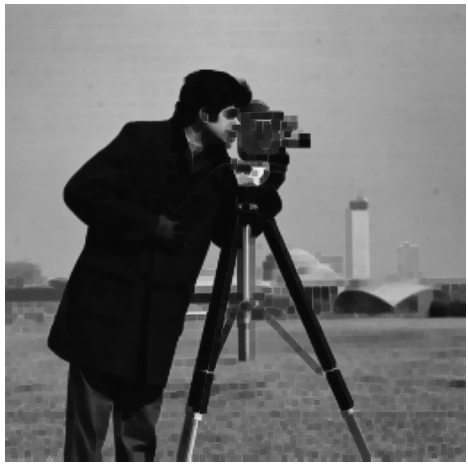

In [4]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow  # Colab-specific display

# Load a sample grayscale image
img = cv2.imread('thr.png', cv2.IMREAD_GRAYSCALE)

# Define structuring element (kernel)
kernel = np.ones((5,5), np.uint8)  # 5×5 square kernel
# Alternatives:
# kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))  # Elliptical
# kernel = cv2.getStructuringElement(cv2.MORPH_CROSS, (5,5))   # Cross-shaped

# Perform erosion
eroded = cv2.erode(img, kernel, iterations=1)

# Display results
print("Original Image:")
cv2_imshow(img)
print("\nEroded Image:")
cv2_imshow(eroded)

# **Opening**

Noisy Image:


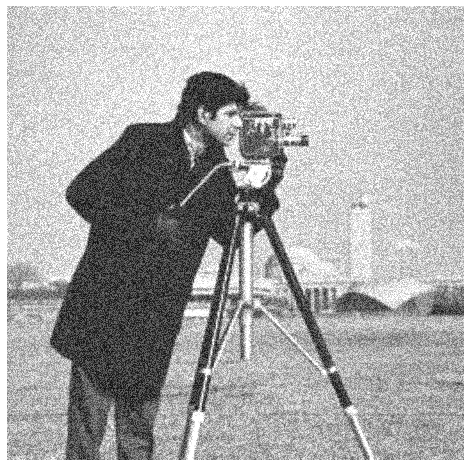


After Opening Operation:


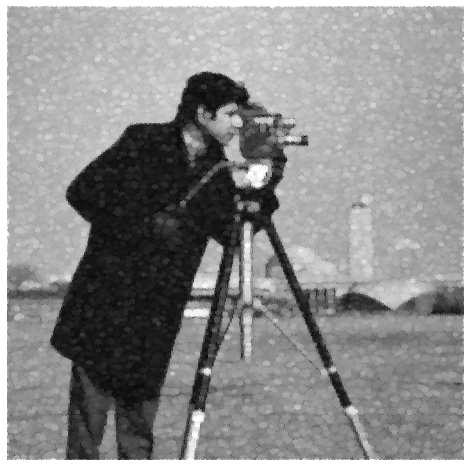

In [5]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# Load a sample grayscale image
img = cv2.imread('thr.png', cv2.IMREAD_GRAYSCALE)

# Add some synthetic noise to demonstrate opening
noisy_img = img.copy()
noise = np.random.randint(0, 100, img.shape, dtype=np.uint8)
noisy_img = cv2.add(img, noise)

# Define structuring element
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))

# Perform opening
opened = cv2.morphologyEx(noisy_img, cv2.MORPH_OPEN, kernel)

# Display results
print("Noisy Image:")
cv2_imshow(noisy_img)
print("\nAfter Opening Operation:")
cv2_imshow(opened)

# **Closing**

Noisy Image with Pepper Noise:


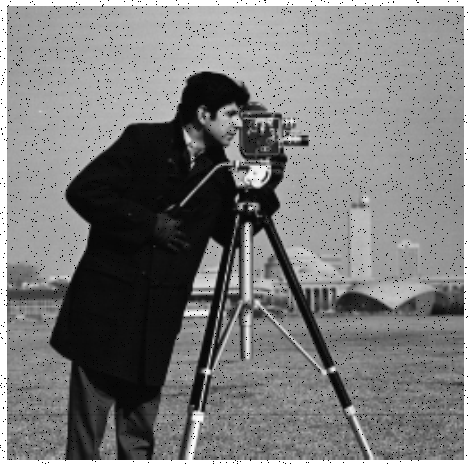


After Closing Operation:


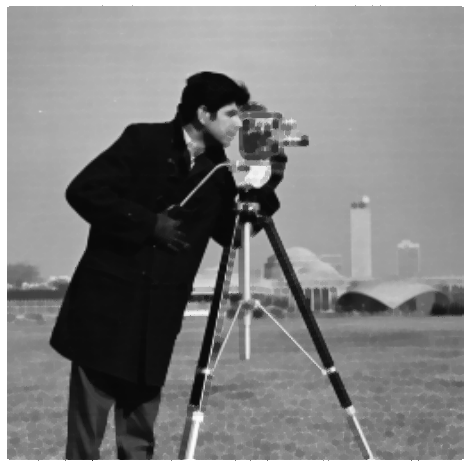

In [6]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# Load sample image and add synthetic pepper noise
img = cv2.imread('thr.png', cv2.IMREAD_GRAYSCALE)

# Create image with pepper noise
noisy_img = img.copy()
pepper_noise = np.random.random(img.shape) < 0.02  # 2% pepper noise
noisy_img[pepper_noise] = 0

# Define structuring element
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))

# Perform closing
closed = cv2.morphologyEx(noisy_img, cv2.MORPH_CLOSE, kernel)

# Display results
print("Noisy Image with Pepper Noise:")
cv2_imshow(noisy_img)
print("\nAfter Closing Operation:")
cv2_imshow(closed)

# **Hit or Miss Transform**

Original Binary Image:


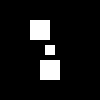


Detected Patterns (Hit-or-Miss Transform):


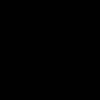

In [7]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# Create a sample binary image
image = np.zeros((100, 100), dtype=np.uint8)
image[20:40, 30:50] = 1  # Rectangle
image[60:80, 40:60] = 1  # Another rectangle
image[45:55, 45:55] = 1  # Small square we want to detect

# Define the pattern (small square) to detect
kernel = np.array([
    [1, 1, 1],
    [1, 1, 1],
    [1, 1, 1]
], dtype=np.uint8) * 255  # 3x3 square pattern

# Perform Hit-or-Miss transform
hitmiss = cv2.morphologyEx(image, cv2.MORPH_HITMISS, kernel)

# Display results
print("Original Binary Image:")
cv2_imshow(image * 255)
print("\nDetected Patterns (Hit-or-Miss Transform):")
cv2_imshow(hitmiss * 255)

Original with L-shapes:


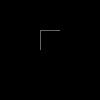


Detection Results (red pixels):


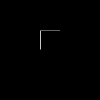

In [8]:
# More complex pattern matching example
image = np.zeros((100, 100), dtype=np.uint8)
# Draw an L-shaped pattern
image[30:50, 40] = 1
image[30, 40:60] = 1

# Define L-shaped pattern kernel (1=foreground, -1=background, 0=don't care)
kernel = np.array([
    [-1,  1,  0],
    [-1,  1,  0],
    [-1,  1, -1]
], dtype=np.int8)

# Perform Hit-or-Miss
hitmiss = cv2.morphologyEx(image, cv2.MORPH_HITMISS, kernel)

# Highlight matches
result = image.copy()
result[hitmiss == 1] = 2  # Mark detections with different value

print("Original with L-shapes:")
cv2_imshow(image * 100)
print("\nDetection Results (red pixels):")
cv2_imshow(result * 100)